<a href="https://colab.research.google.com/github/BKover99/epitome_tools_star_protocols/blob/main/STAR_Protocols_process_and_annotate_multiome_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Jupyter notebook accompanies the STAR Protocols manuscript (Kover, Dogan, Goddard, Andoniadou; 2026). While the protocols shows RNA and ATAC analysis simulatenously, here we structured the notebook such that first the RNA workflow is shown, which is then followed by the ATAC workflow.



## Install packages

In [ ]:
pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 142.0 MB/s eta 0:00:00
  Cloning https://github.com/googlecolab/kernel_gateway (to revision b134e9945df25c2dcb98ade9129399be10788671) to /tmp/pip-install-1iew_mo3/jupyter-kernel-gateway_648d7a93db6149d69d31b6861ce22d81
  Running command git clone --filter=blob:none --quiet https://github.com/googlecolab/kernel_gateway /tmp/pip-install-1iew_mo3/jupyter-kernel-gateway_648d7a93db6149d69d31b6861ce22d81
  Running command git rev-parse -q --verify 'sha^b134e9945df25c2dcb98ade9129399be10788671'
  Running command git fetch -q https://github.com/googlecolab/kernel_gateway b134e9945df25c2dcb98ade9129399be10788671
  Running command git checkout -q b134e9945df25c2dcb98ade9129399be10788671
  Resolved https://github.com/googlecolab/kernel_gateway to commit b134e9945df25c2dcb98ade9129399be10788671
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install scanpy
!pip install igraph
!pip install leidenalg
!pip install ffq
!pip install epitome_tools --upgrade
!pip install --user scikit-misc
!pip install --upgrade polars anndata snapatac2 --force-reinstall
!pip install "scikit-learn==1.7.0"
!pip install numpy==2.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 88.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 MB 35.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for epitome_tools: filename=epitome_tools-1.0.8-py3-none-any.whl size=80075072 sha256=f7a90bd07873d615df1fb5b75421fad4333104ecb1193357efb03b893737928e
  Stored in directory: /root/.cache/pip/wheels/62/65/17/765df659060

In [ ]:
!pip install "scikit-learn==1.7.0"

In [ ]:
!pip install --user scikit-misc

In [ ]:
!pip install "numpy<2.1"

## Mount google drive, in case you would like to save files as checkpoints or long term storage

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#suppress all warnings
import warnings
warnings.filterwarnings('ignore')

# Finding run accessions for datasets


NCBI: SRX30501235 and SRX30501234

As shown on https://www.ncbi.nlm.nih.gov/sra, these datasets consist of the following runs:

SRX30501235: SRR35421867

SRX30501234: SRR35421868

# Downloading fastq files from the SRA for each corresponding run

While we will not download these files here into a google colab, the reader can do this in their own environment (locally or HPC) by executing the following code



```
install sudo apt install sra-toolkit

!for id in SRR35421867 SRR35421868; do prefetch --max-size 500G $id && fastq-dump --outdir /target_dir/ --gzip --split-files $id; done
```



Beyond this point, we assume that the reader has run Cell Ranger or is comfortable with moving forward with the files pre-processed by us. At this point, ensure that the required files are present in the environment, either through downloading them in the next code block, or uploading them to the right folder (e.g. onto Google Colab) for access.

# Downloading datasets from Zenodo - Approx. 20 mins

In [8]:
import os

# Below are the zenodo IDs corresponding to each dataset
files = {
    "SRX30501234_atac_outs.zip": "04f995e0254d21f96bd814628a8875ef",
    "SRX30501235_rna_outs.zip":  "81ac5586108bd9fcccc7920fd68b19d8"
}

base = "https://zenodo.org/records/20749243/files/{}?download=1"

# Setup directory
os.makedirs("/content/zenodo/", exist_ok=True)

for name in files:
    url = base.format(name)
    #download
    !wget -c -O "/content/zenodo/{name}" "{url}"
    #unzip
    !unzip -q "/content/zenodo/{name}" -d /content/zenodo/

--2026-07-11 13:02:56--  https://zenodo.org/records/20749243/files/SRX30501234_atac_outs.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.184.103.118, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1816363915 (1.7G) [application/octet-stream]
Saving to: ‘/content/zenodo/SRX30501234_atac_outs.zip’

/content/zenodo/SRX 100%[===================>]   1.69G  4.03MB/s    in 4m 36s  

2026-07-11 13:07:32 (6.28 MB/s) - ‘/content/zenodo/SRX30501234_atac_outs.zip’ saved [1816363915/1816363915]

--2026-07-11 13:07:51--  https://zenodo.org/records/20749243/files/SRX30501235_rna_outs.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.98.114, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 194503354 (185M) [application/octet-stream]
Saving to: ‘/content/zenod

# Restart kernel here!

Load dataset - Approx. 1 min


In [1]:
import scanpy as sc
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation as mad

In [75]:
adata_mm = sc.read_10x_h5("/content/zenodo/SRX30501235_rna_outs/raw_feature_bc_matrix.h5")

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Filtering dataset

In [76]:
def qc1(adata,min_genes=800, min_counts=1000):
    #QC function, filtering cells and genes,
    #adding mitochondrial and ribosomal flags to adata.var
    #and calculating general QC metrics
    sc.pp.filter_cells(adata, min_genes = min_genes)
    sc.pp.filter_cells(adata, min_counts = min_counts)

    mt_tag="mt-"
    ribo_tag=("Rps","Rpl")
    malat_tag = "Malat1"

    adata.var["mt"] = adata.var_names.str.startswith(mt_tag)
    adata.var["ribo"] = adata.var_names.str.startswith(ribo_tag)
    adata.var["malat"] = adata.var_names.str.startswith(malat_tag)

    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "malat"], inplace=True, percent_top=[20], log1p=True)
    return adata


def mad_outlier(adata, metric, nmads, upper_only = False, value = False):
  #function to calculate median absolute deviation cut-offs
    if value and upper_only:
      upper_val = np.median(adata.obs[metric]) + nmads * mad(adata.obs[metric])
      return [upper_val,0]
    elif value and not upper_only:
      upper_val = np.median(adata.obs[metric]) + nmads * mad(adata.obs[metric])
      lower_val = np.median(adata.obs[metric]) - nmads * mad(adata.obs[metric])
      return [upper_val,lower_val]
    else:
      M = adata.obs[metric]

      if not upper_only:
          return (M < np.median(M) - nmads * mad(M)) | (M > np.median(M) + nmads * mad(M))

    return (M > np.median(M) + nmads * mad(M))

def violinplot(ax, adata, col, vals):
    #function to generate violin plots with red cut-off lines
    values = adata.obs[col].values
    sns.violinplot(y=values, ax=ax)
    for v in vals:
        ax.axhline(v, color='red')
    ax.set_title(col)
    ax.set_ylabel('')

def qc2(adata):
    #second QC function, filtering cells based on multiple criteria, using
    #median absolute deviation cut-offs as shown on the violin plots
    mt_val = mad_outlier(adata, 'pct_counts_mt', 5, upper_only=True, value=True)
    ribo_val = mad_outlier(adata, 'pct_counts_ribo', 5, upper_only=True, value=True)
    malat_val = mad_outlier(adata, 'pct_counts_malat', 5, upper_only=True, value=True)
    log1p_n_genes_val = mad_outlier(adata, 'log1p_n_genes_by_counts', 4, upper_only=False, value=True)
    log1p_total_val = mad_outlier(adata, 'log1p_total_counts', 4, upper_only=False, value=True)
    top_genes_val = mad_outlier(adata, 'pct_counts_in_top_20_genes', 5, upper_only=True, value=True)

    # Generate panel of violin plots
    fig, axs = plt.subplots(2, 3, figsize=(8, 5.5))
    axs = axs.flatten()

    violinplot(axs[0], adata, 'pct_counts_mt', mt_val + [25])
    violinplot(axs[1], adata, 'pct_counts_ribo', ribo_val + [30])
    violinplot(axs[2], adata, 'pct_counts_malat', malat_val)
    violinplot(axs[3], adata, 'log1p_n_genes_by_counts', log1p_n_genes_val)
    violinplot(axs[4], adata, 'log1p_total_counts', log1p_total_val)
    violinplot(axs[5], adata, 'pct_counts_in_top_20_genes', top_genes_val)

    plt.tight_layout()
    plt.savefig(f"vlnplot.png", dpi=800)
    plt.savefig(f"vlnplot.svg", format="svg", bbox_inches="tight")

    adata = adata[adata.obs.pct_counts_mt < 25]
    adata = adata[adata.obs.pct_counts_ribo < 30]

    #create boolean filter to remove cells
    bool_vector = mad_outlier(adata, 'pct_counts_mt', 5, upper_only=True) + \
                  mad_outlier(adata, 'pct_counts_ribo', 5, upper_only=True) + \
                  mad_outlier(adata, 'pct_counts_malat', 5, upper_only=True) + \
                  mad_outlier(adata, 'log1p_n_genes_by_counts', 4) + \
                  mad_outlier(adata, 'log1p_total_counts', 4) + \
                  mad_outlier(adata, 'pct_counts_in_top_20_genes', 5, upper_only=True)

    adata = adata[~bool_vector]
    adata.uns['cells_removed'] = sum(bool_vector)

    return adata, fig


Running the filtering - Approx. 1 min

Initial dataset: 637,237 cells × 33,696 genes


/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


After QC1:       4,083 cells × 33,696 genes


/tmp/ipython-input-76-4096301172.py:83: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['cells_removed'] = sum(bool_vector)
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


After QC2:       3,539 cells × 33,696 genes


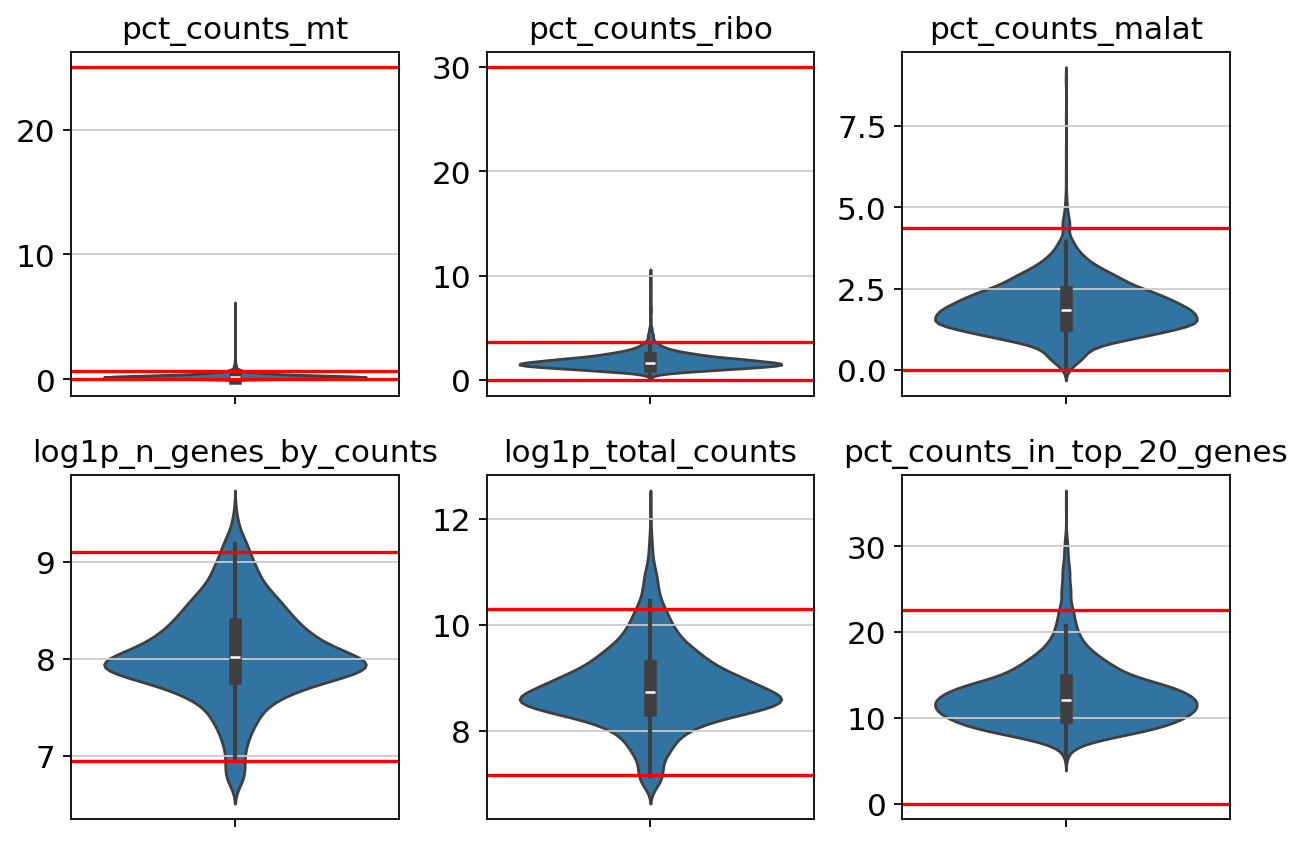

In [77]:
print(f"Initial dataset: {adata_mm.shape[0]:,} cells × {adata_mm.shape[1]:,} genes")

adata_mm= qc1(adata_mm)
print(f"After QC1:       {adata_mm.shape[0]:,} cells × {adata_mm.shape[1]:,} genes")

adata_mm, violinplots = qc2(adata_mm)
print(f"After QC2:       {adata_mm.shape[0]:,} cells × {adata_mm.shape[1]:,} genes")

Normalisation, PCA, UMAP standard workflow - Approx. 1 min

/usr/local/lib/python3.11/dist-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


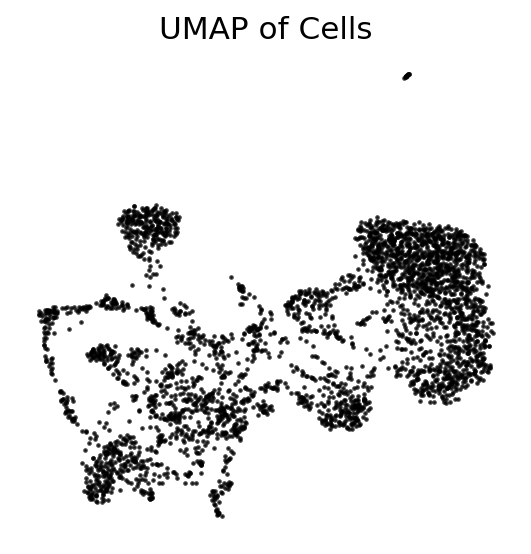

In [78]:
def to_umap(adata):
  #function to generate UMAP for normalized dataset
  # Highly variable genes
  sc.pp.highly_variable_genes(adata, flavor="seurat_v3",n_top_genes=2000,subset=False)

  # PCA using only HVGs
  sc.pp.pca(adata, n_comps=42, use_highly_variable=True, svd_solver="arpack")

  # Compute neighborhood graph
  sc.pp.neighbors(adata, n_neighbors=15, n_pcs=42)

  # UMAP
  sc.tl.umap(adata, random_state=42)
  ax = sc.pl.umap(adata, size=5, alpha=0.7, frameon=False, title="UMAP of Cells", color=None, show=False)
  ax.collections[0].set_color("black")
  plt.savefig(f"umap.png", dpi=800)
  plt.show()

# Set high-resolution saving
sc.settings.figdir = "./figures"
sc.set_figure_params(dpi_save=600)

adata_mm.layers["raw_counts"] = adata_mm.X.copy()
sc.pp.normalize_total(adata_mm, target_sum=1e4)
sc.pp.log1p(adata_mm)
to_umap(adata_mm)

# Running epitome_tools for doublet detection - Approx. 5-10 seconds

In [79]:
from epitome_tools.workflow import doublet_workflow
import time

start_mm = time.time()

doublet_workflow(
  adata_mm,
  active_assay="multi_rna",
  modality="rna",
  in_place=True,
  nan_or_zero='zero',
  species="mouse"
                              )

end_mm = time.time()
print(f"Time taken for dataset: {end_mm - start_mm} seconds")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Percentage of features present in adata: 98.00%
At least 70% of the features are present in the adata object.
The dataset has passed the compatibility check.
Time taken for dataset: 7.4933836460113525 seconds


In [80]:
#show all cols
pd.set_option('display.max_columns', None)

In [81]:
adata_mm.obs

,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,pct_counts_kept,init_predicted_doublet_epitome,thresholded_doublet_epitome,doublet_score_epitome,final_doublet_label,doublet_uncertainty
AAACAGCCAAGGATTA-1,5453,14451.0,5453,8.604105,14451.0,9.578588,10.206906,50.0,3.931826,0.345997,352.0,5.866468,2.435817,295.0,5.690360,2.041381,0.300394,doublet,True,0.793420,doublet,0.206580
AAACAGCCAGCATGAG-1,2628,4906.0,2628,7.874359,4906.0,8.498418,15.246637,22.0,3.135494,0.448431,107.0,4.682131,2.181003,70.0,4.262680,1.426824,0.334896,real,False,0.029172,real,0.029172
AAACAGCCATAAGTTC-1,4818,11412.0,4818,8.480322,11412.0,9.342508,7.974062,68.0,4.234107,0.595864,214.0,5.370638,1.875219,95.0,4.564348,0.832457,0.350771,doublet,True,0.978573,doublet,0.021427
AAACAGCCATATAACC-1,4028,9570.0,4028,8.301273,9570.0,9.166493,10.052247,3.0,1.386294,0.031348,92.0,4.532599,0.961338,136.0,4.919981,1.421108,0.285266,doublet,False,0.600094,real,0.399906
AAACATGCAGATTCAT-1,5042,13107.0,5042,8.525756,13107.0,9.480978,8.148318,14.0,2.708050,0.106813,243.0,5.497168,1.853971,224.0,5.416101,1.709010,0.326619,real,False,0.385295,real,0.385295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACTAAAC-1,5812,18329.0,5812,8.667852,18329.0,9.816295,11.304490,21.0,3.091043,0.114573,222.0,5.407172,1.211195,396.0,5.983936,2.160511,0.373779,doublet,True,0.937629,doublet,0.062371
TTTGTTGGTCGACTCC-1,2727,5241.0,2727,7.911324,5241.0,8.564459,12.593017,4.0,1.609438,0.076321,69.0,4.248495,1.316543,115.0,4.753590,2.194238,0.333143,real,False,0.319781,real,0.319781
TTTGTTGGTTAATGCG-1,8047,26619.0,8047,8.993179,26619.0,10.189418,7.517187,63.0,4.158883,0.236673,646.0,6.472346,2.426838,462.0,6.137727,1.735602,0.328525,doublet,True,0.958066,doublet,0.041934
TTTGTTGGTTCCGCAC-1,2559,4961.0,2559,7.847763,4961.0,8.509564,15.440435,3.0,1.386294,0.060472,81.0,4.406719,1.632735,90.0,4.510859,1.814150,0.345696,real,False,0.179596,real,0.179596


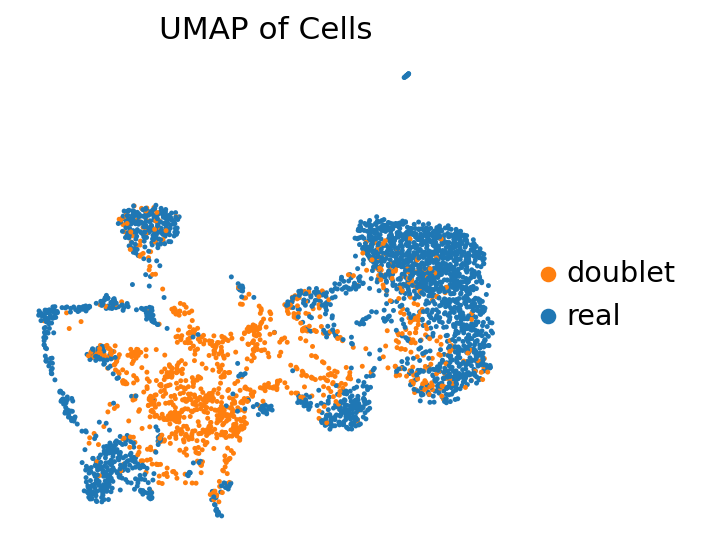

In [82]:
def plot_cells(adata, column,palette=sc.pl.palettes.default_20):
    sc.pl.umap(
        adata,
        color=column,
        palette=palette,
        size=20,
        alpha=1,
        frameon=False,
        title="UMAP of Cells",
        save=f"_{column}.png",
        show=True,
    )

plot_cells(adata_mm, "final_doublet_label", palette={"real": "#1f77b4","doublet": "#ff7f0e"})

### Below we can explore the values assigned by epitome_tools to each cell in adata.obs. Specifically, in the columns:
 'init_predicted_doublet_epitome', 'thresholded_doublet_epitome', 'doublet_score_epitome', 'final_doublet_label', 'doublet_uncertainty'

# Removing doublets

In [84]:
adata_mm.obs

,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,pct_counts_kept,init_predicted_doublet_epitome,thresholded_doublet_epitome,doublet_score_epitome,final_doublet_label,doublet_uncertainty
AAACAGCCAAGGATTA-1,5453,14451.0,5453,8.604105,14451.0,9.578588,10.206906,50.0,3.931826,0.345997,352.0,5.866468,2.435817,295.0,5.690360,2.041381,0.300394,doublet,True,0.793420,doublet,0.206580
AAACAGCCAGCATGAG-1,2628,4906.0,2628,7.874359,4906.0,8.498418,15.246637,22.0,3.135494,0.448431,107.0,4.682131,2.181003,70.0,4.262680,1.426824,0.334896,real,False,0.029172,real,0.029172
AAACAGCCATAAGTTC-1,4818,11412.0,4818,8.480322,11412.0,9.342508,7.974062,68.0,4.234107,0.595864,214.0,5.370638,1.875219,95.0,4.564348,0.832457,0.350771,doublet,True,0.978573,doublet,0.021427
AAACAGCCATATAACC-1,4028,9570.0,4028,8.301273,9570.0,9.166493,10.052247,3.0,1.386294,0.031348,92.0,4.532599,0.961338,136.0,4.919981,1.421108,0.285266,doublet,False,0.600094,real,0.399906
AAACATGCAGATTCAT-1,5042,13107.0,5042,8.525756,13107.0,9.480978,8.148318,14.0,2.708050,0.106813,243.0,5.497168,1.853971,224.0,5.416101,1.709010,0.326619,real,False,0.385295,real,0.385295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACTAAAC-1,5812,18329.0,5812,8.667852,18329.0,9.816295,11.304490,21.0,3.091043,0.114573,222.0,5.407172,1.211195,396.0,5.983936,2.160511,0.373779,doublet,True,0.937629,doublet,0.062371
TTTGTTGGTCGACTCC-1,2727,5241.0,2727,7.911324,5241.0,8.564459,12.593017,4.0,1.609438,0.076321,69.0,4.248495,1.316543,115.0,4.753590,2.194238,0.333143,real,False,0.319781,real,0.319781
TTTGTTGGTTAATGCG-1,8047,26619.0,8047,8.993179,26619.0,10.189418,7.517187,63.0,4.158883,0.236673,646.0,6.472346,2.426838,462.0,6.137727,1.735602,0.328525,doublet,True,0.958066,doublet,0.041934
TTTGTTGGTTCCGCAC-1,2559,4961.0,2559,7.847763,4961.0,8.509564,15.440435,3.0,1.386294,0.060472,81.0,4.406719,1.632735,90.0,4.510859,1.814150,0.345696,real,False,0.179596,real,0.179596


In [85]:
adata_mm = adata_mm[adata_mm.obs.final_doublet_label == "real"]
adata_mm

View of AnnData object with n_obs × n_vars = 2423 × 33696
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_malat', 'log1p_total_counts_malat', 'pct_counts_malat', 'pct_counts_kept', 'init_predicted_doublet_epitome', 'thresholded_doublet_epitome', 'doublet_score_epitome', 'final_doublet_label', 'doublet_uncertainty'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'malat', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cells_removed', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'final_doublet_label_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_counts'
 

In [72]:
adata_mm.obs

,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,pct_counts_kept,init_predicted_doublet_epitome,thresholded_doublet_epitome,doublet_score_epitome,final_doublet_label,doublet_uncertainty


# Running epitome_tools for cell typing - Approx. 5-10 seconds

In [87]:
from epitome_tools.workflow import cell_type_workflow, doublet_workflow
import time

start_mm = time.time()

cell_type_workflow(
  adata_mm,
  active_assay="multi_rna",
  modality="rna",
  in_place=True,
  species="mouse",
  smoothing=True
                              )

end_mm = time.time()
print(f"Time taken for dataset: {end_mm - start_mm} seconds")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Percentage of features present in adata: 98.04%
At least 70% of the features are present in the adata object.
The dataset has passed the compatibility check.
Time taken for dataset: 8.404168844223022 seconds


### Below we can explore the values assigned by epitome_tools to each cell in adata.obs. Specifically, in the columns:
predicted_cell_type 	predicted_cell_type_proba 	cell_type_uncertainty 	proba_Corticotrophs 	proba_Endothelial_cells 	proba_Erythrocytes 	proba_Gonadotrophs 	proba_Immune_cells 	proba_Lactotrophs 	proba_Melanotrophs 	proba_Mesenchymal_cells 	proba_Pituicytes 	proba_Somatotrophs 	proba_Stem_cells 	proba_Thyrotrophs

In [88]:
adata_mm.obs

,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,pct_counts_kept,init_predicted_doublet_epitome,thresholded_doublet_epitome,doublet_score_epitome,final_doublet_label,doublet_uncertainty,predicted_cell_type,predicted_cell_type_proba,cell_type_uncertainty,proba_Corticotrophs,proba_Endothelial_cells,proba_Erythrocytes,proba_Gonadotrophs,proba_Immune_cells,proba_Lactotrophs,proba_Melanotrophs,proba_Mesenchymal_cells,proba_Pituicytes,proba_Somatotrophs,proba_Stem_cells,proba_Thyrotrophs,cell_type_final
AAACAGCCAGCATGAG-1,2628,4906.0,2628,7.874359,4906.0,8.498418,15.246637,22.0,3.135494,0.448431,107.0,4.682131,2.181003,70.0,4.262680,1.426824,0.334896,real,False,0.029172,real,0.029172,Somatotrophs,0.942564,0.057436,0.004508,0.000562,0.000339,0.003076,0.000890,0.002672,0.007832,0.001468,0.002105,0.942564,0.000696,0.033288,Somatotrophs
AAACAGCCATATAACC-1,4028,9570.0,4028,8.301273,9570.0,9.166493,10.052247,3.0,1.386294,0.031348,92.0,4.532599,0.961338,136.0,4.919981,1.421108,0.285266,doublet,False,0.600094,real,0.399906,Somatotrophs,0.950647,0.049353,0.004482,0.000553,0.000373,0.004792,0.001152,0.007121,0.001389,0.002182,0.003080,0.950647,0.000953,0.023275,Somatotrophs
AAACATGCAGATTCAT-1,5042,13107.0,5042,8.525756,13107.0,9.480978,8.148318,14.0,2.708050,0.106813,243.0,5.497168,1.853971,224.0,5.416101,1.709010,0.326619,real,False,0.385295,real,0.385295,Stem_cells,0.996246,0.003754,0.000204,0.000075,0.000039,0.000270,0.000076,0.000445,0.000599,0.000224,0.000170,0.001240,0.996246,0.000413,Stem_cells
AAACCGAAGTAATCCA-1,2940,5452.0,2940,7.986505,5452.0,8.603921,15.590609,20.0,3.044523,0.366838,121.0,4.804021,2.219369,68.0,4.234107,1.247249,0.304109,real,False,0.221166,real,0.221166,Somatotrophs,0.990040,0.009960,0.000558,0.000209,0.000132,0.001586,0.000434,0.002030,0.000424,0.000769,0.000846,0.990040,0.000247,0.002725,Somatotrophs
AAACCGCGTACCTTAC-1,3923,9184.0,3923,8.274867,9184.0,9.125327,14.503484,34.0,3.555348,0.370209,152.0,5.030438,1.655052,376.0,5.932245,4.094077,0.398737,doublet,False,0.549013,real,0.450987,Thyrotrophs,0.980320,0.019680,0.001711,0.000085,0.000058,0.014028,0.000099,0.001397,0.000586,0.000283,0.000354,0.000933,0.000148,0.980320,Thyrotrophs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGGCAATTGAAG-1,2830,5561.0,2830,7.948385,5561.0,8.623713,13.558712,20.0,3.044523,0.359648,120.0,4.795791,2.157885,119.0,4.787492,2.139903,0.348678,real,False,0.259954,real,0.259954,Somatotrophs,0.962054,0.037946,0.002830,0.000474,0.000281,0.009346,0.001146,0.001261,0.008652,0.000937,0.002357,0.962054,0.000572,0.010090,Somatotrophs
TTTGTGGCAGGGAGCT-1,2331,4193.0,2331,7.754482,4193.0,8.341411,13.784880,4.0,1.609438,0.095397,42.0,3.761200,1.001669,77.0,4.356709,1.836394,0.373003,real,False,0.431094,real,0.431094,Corticotrophs,0.976122,0.023878,0.976122,0.000190,0.000060,0.000681,0.000163,0.000423,0.000391,0.000525,0.001250,0.000974,0.000240,0.018981,Corticotrophs
TTTGTGTTCGGGACTC-1,3508,6453.0,3508,8.163086,6453.0,8.772455,7.190454,27.0,3.332205,0.418410,187.0,5.236442,2.897877,50.0,3.931826,0.774833,0.298311,real,False,0.076007,real,0.076007,Stem_cells,0.993611,0.006389,0.000346,0.000063,0.000046,0.000775,0.000089,0.000494,0.000185,0.000149,0.000201,0.003462,0.993611,0.000578,Stem_cells
TTTGTTGGTCGACTCC-1,2727,5241.0,2727,7.911324,5241.0,8.564459,12.593017,4.0,1.609438,0.076321,69.0,4.248495,1.316543,115.0,4.753590,2.194238,0.333143,real,False,0.319781,real,0.319781,Somatotrophs,0.961600,0.038400,0.006290,0.000743,0.000455,0.005518,0.000889,0.004829,0.001281,0.001804,0.002754,0.961600,0.002746,0.011091,Somatotrophs


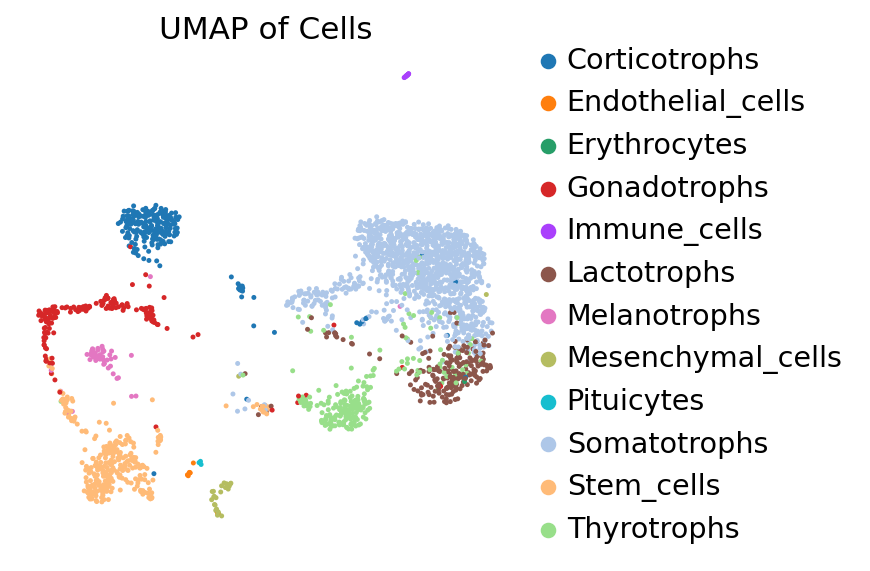

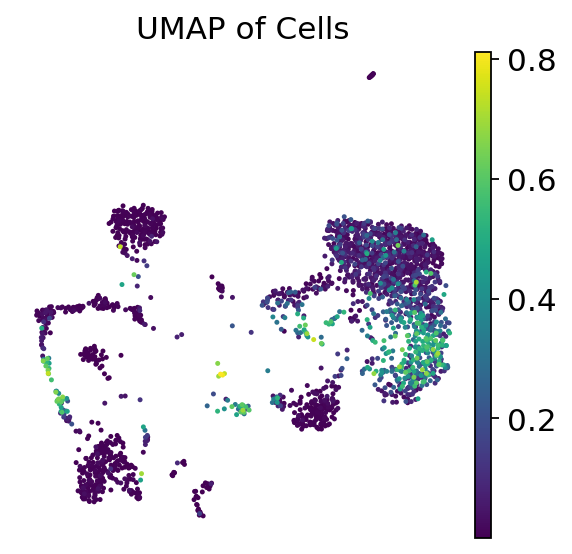

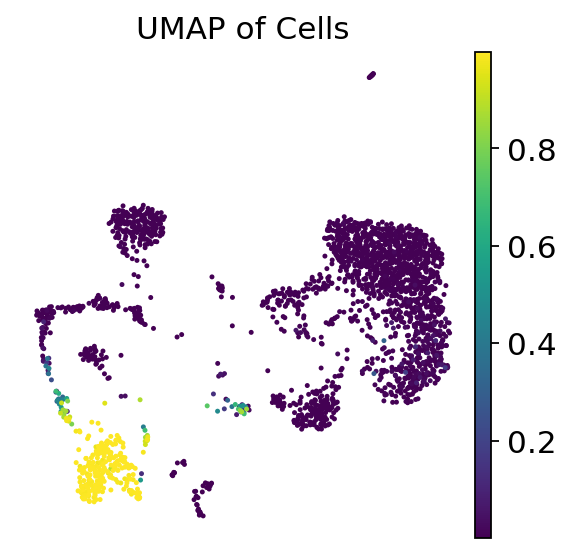

In [89]:
plot_cells(adata_mm,"predicted_cell_type")
plot_cells(adata_mm,"cell_type_uncertainty")
plot_cells(adata_mm,"proba_Stem_cells")

/tmp/ipython-input-90-1515747990.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sc_gonado_subset.obs["sc_gonado_pseudotime"] = (


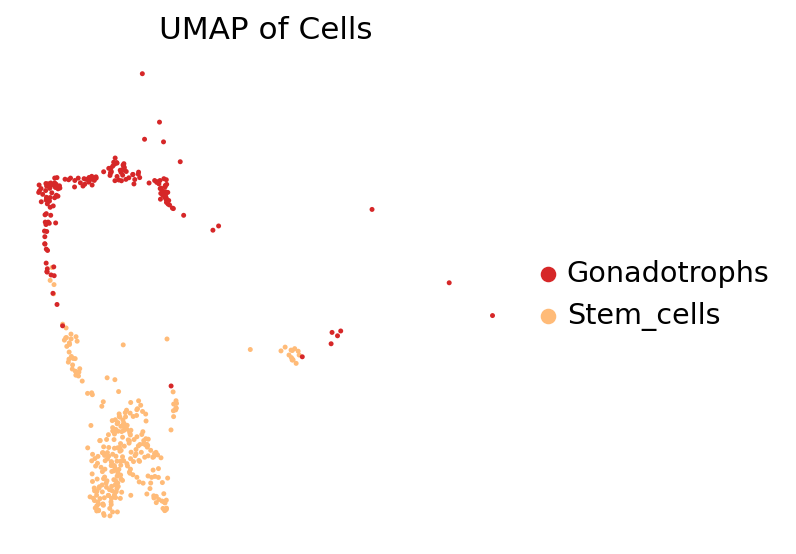

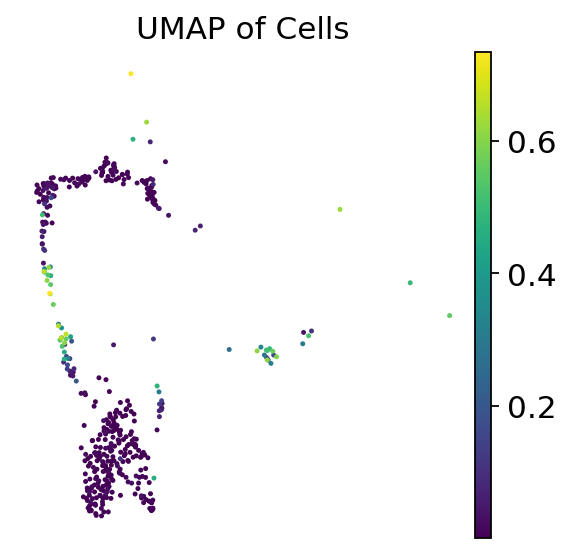

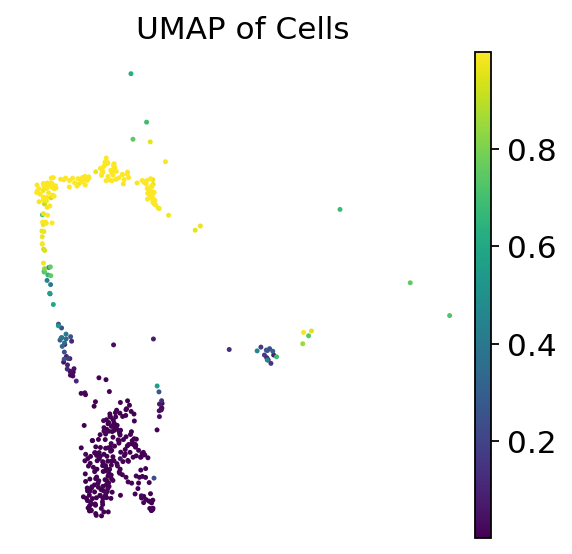

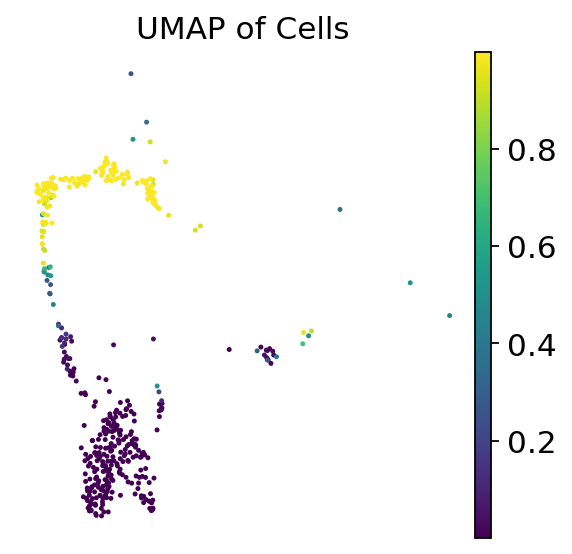

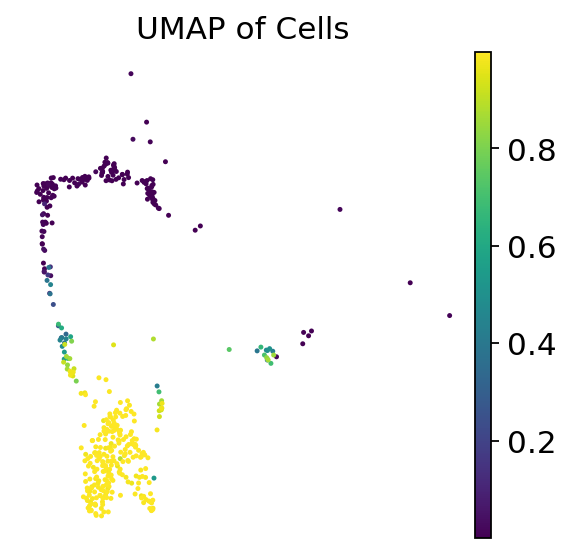

In [90]:
sc_gonado_subset = adata_mm[adata_mm.obs["predicted_cell_type"].isin(["Stem_cells","Gonadotrophs"])]
sc_gonado_subset.obs["sc_gonado_pseudotime"] = (
    sc_gonado_subset.obs["proba_Gonadotrophs"] - sc_gonado_subset.obs["proba_Stem_cells"] + 1) / 2

plot_cells(sc_gonado_subset,"predicted_cell_type",
           palette = [sc.pl.palettes.default_20[3], sc.pl.palettes.default_20[10]])
plot_cells(sc_gonado_subset,"cell_type_uncertainty")
plot_cells(sc_gonado_subset,"sc_gonado_pseudotime")
plot_cells(sc_gonado_subset,"proba_Gonadotrophs")
plot_cells(sc_gonado_subset,"proba_Stem_cells")

# Generate a dot plot of canonical marker genes of pituitary gland cell types - Approx. 1 min


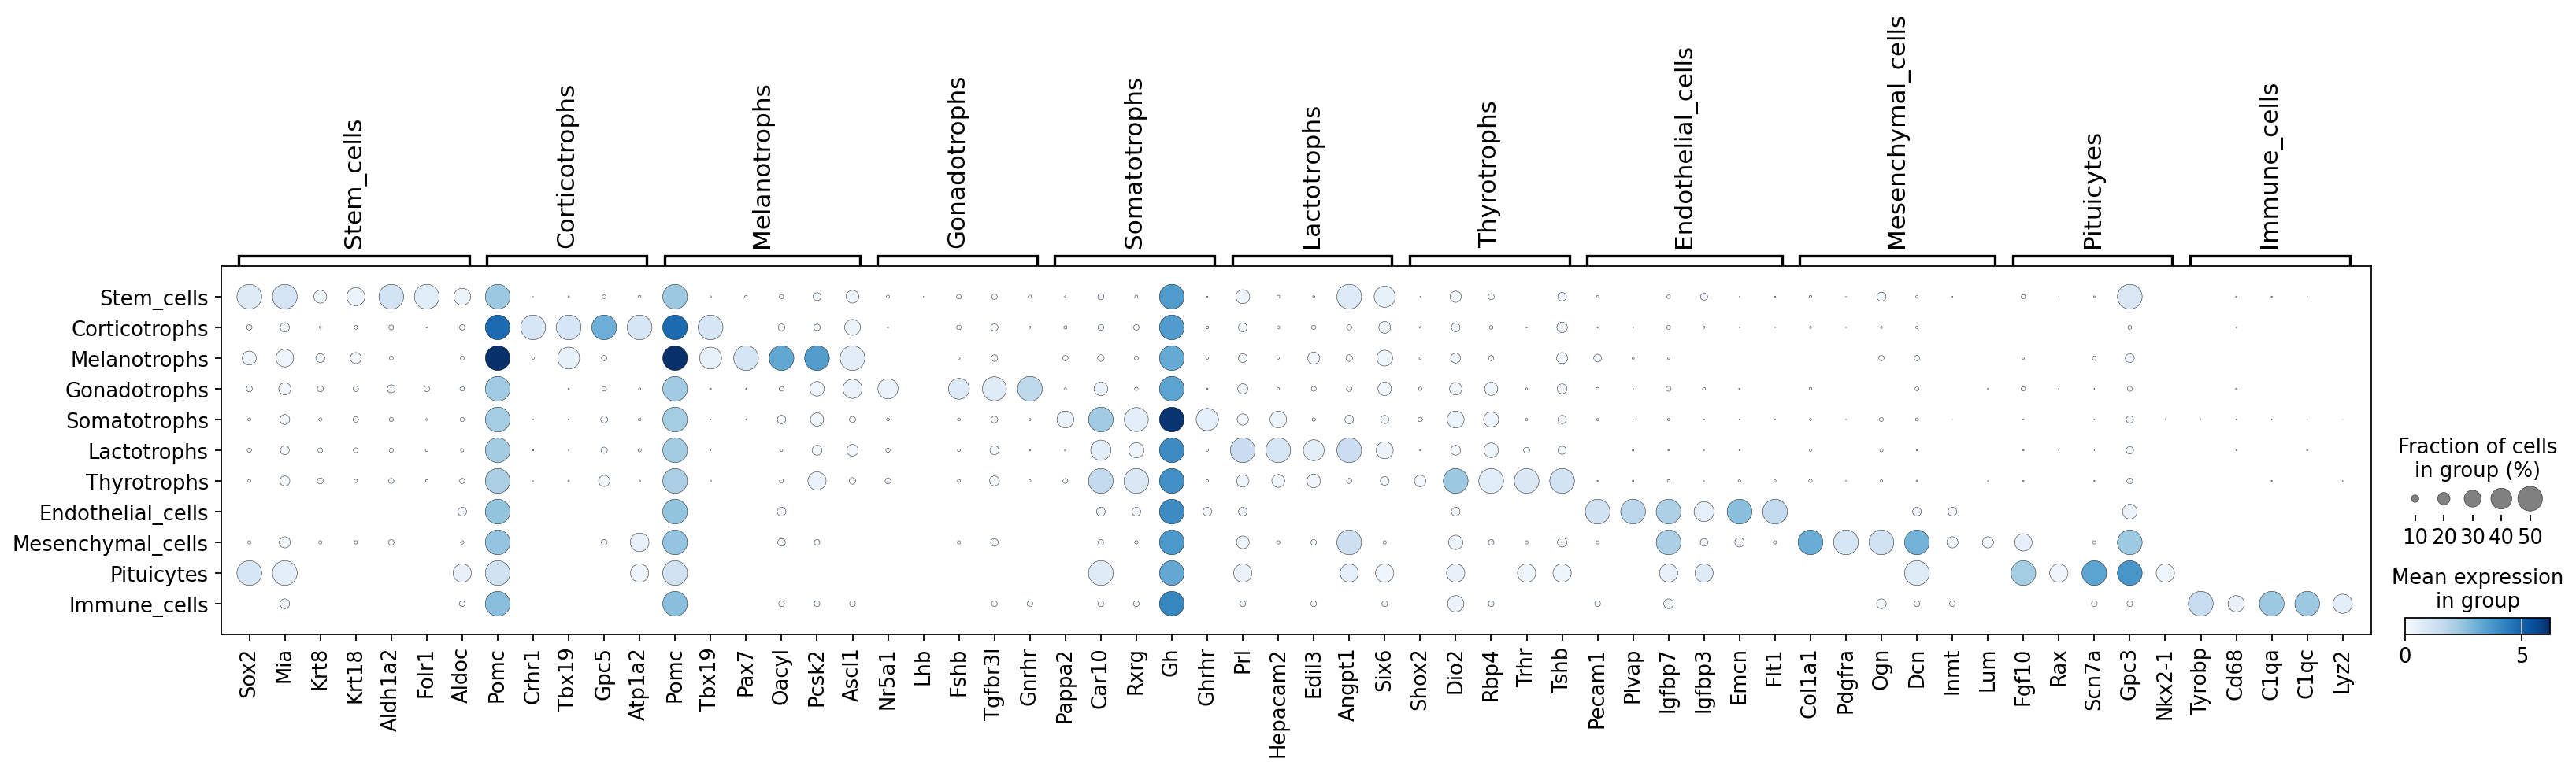

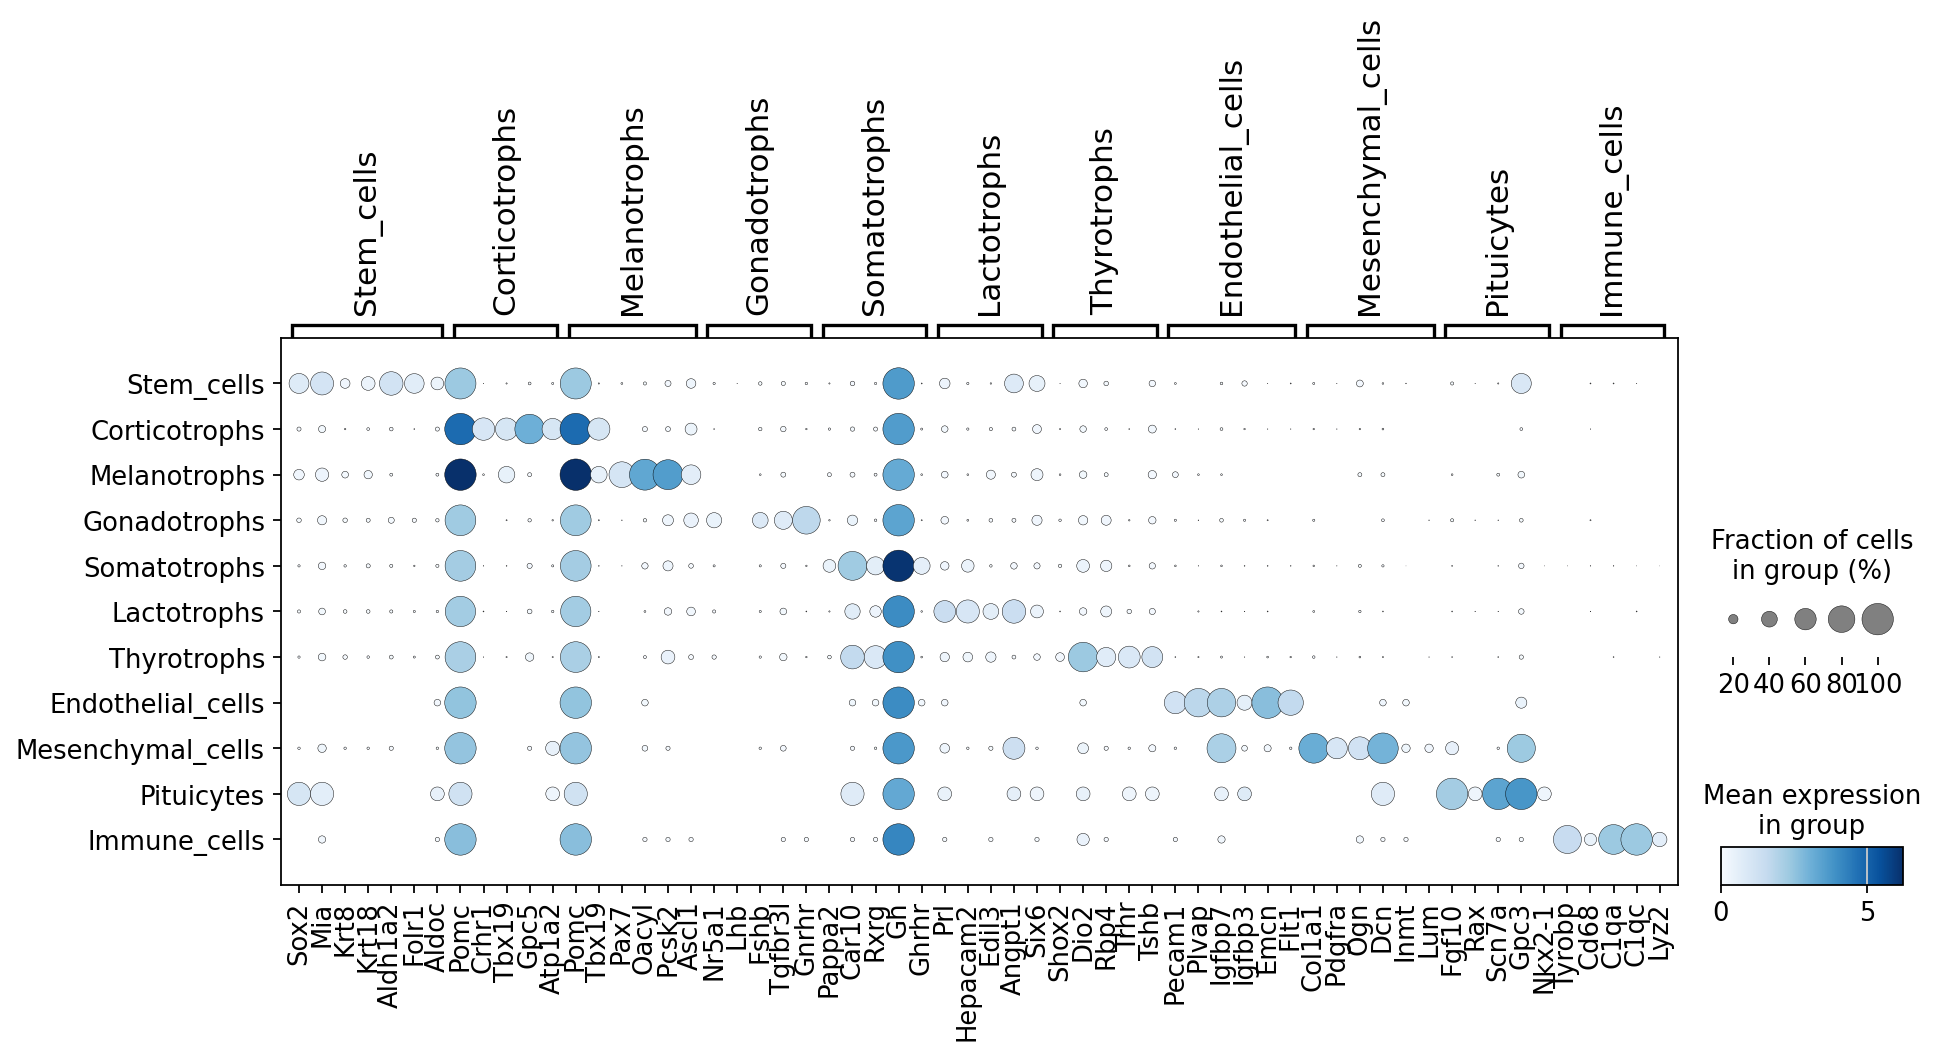

In [91]:
mouse_markers = {"Stem_cells": ["Sox2", "Mia", "Krt8", "Krt18","Aldh1a2", "Folr1", "Aldoc"],
    "Corticotrophs": ["Pomc", "Crhr1", "Tbx19", "Gpc5", "Tnt1", "Atp1a2"],
    "Melanotrophs": ["Pomc", "Tbx19", "Pax7", "Oacyl", "Pcsk2", "Ascl1" ],
    "Gonadotrophs": ["Nr5a1", "Lhb", "Fshb", "Tgfbr3l", "Gnrhr"],
    "Somatotrophs": ["Pappa2", "Car10", "Rxrg", "Gh", "Ghrhr"],
    "Lactotrophs": ["Prl", "Hepacam2", "Edil3", "Angpt1",  "Six6"],
    "Thyrotrophs": ["Shox2", "Dio2", "Rbp4", "Trhr", "Tshb" ],
    "Endothelial_cells": ["Pecam1", "Plvap", "Igfbp7", "Igfbp3", "Emcn", "Flt1" ],
    "Mesenchymal_cells": ["Col1a1", "Pdgfra", "Ogn", "Dcn", "Inmt", "Lum"],
    "Pituicytes": [ "Fgf10", "Rax", "Scn7a", "Gpc3", "Nkx2-1"],
    "Immune_cells": ["Tyrobp", "Cd68", "C1qa", "C1qc", "Lyz2" ]}

# Filter the marker genes to those included in the object
mouse_markers = {k: [x for x in v if x in adata_mm.var_names] for k, v in mouse_markers.items()}

# Extract the intended order from your dictionary keys
cell_type_order = list(mouse_markers.keys())

#only keep those that are in cell_type_final
cell_type_order = [x for x in cell_type_order if x in adata_mm.obs["predicted_cell_type"].unique()]

# Cast the observation column to a Categorical type with the strict order
adata_mm.obs["predicted_cell_type"] = pd.Categorical(adata_mm.obs["predicted_cell_type"],
    categories=cell_type_order,
    ordered=True
)

sc.pl.dotplot(adata_mm, mouse_markers, groupby="predicted_cell_type",save="_dotplot_markers.png",
              cmap="Blues", dot_max=0.5,use_raw=False)
sc.pl.dotplot(adata_mm, mouse_markers, figsize=(13,4.5), groupby="predicted_cell_type",
              save="_dotplot_markers.svg",cmap="Blues",use_raw=False)

# Generate a dot plot of highly specific markers from the Consensus Pituitary Atlas. - Approx. 1 min


In [ ]:
mouse_cpa_markers = {
    "Stem_cells": ["Cdh26", "Agr3", "Alox12e", "Klhl31", "Grin2a"],
    "Corticotrophs": ["Cdh8", "Avpr1b", "Alpk2", "Qrfpr", "Ano3"],
    "Melanotrophs": ["Grik1", "Gulo", "Col19a1", "Rbfox3", "Ppp1r17"],
    "Gonadotrophs": ["Bean1", "Hmcn2", "Cfap73", "Drd3", "Cntnap5c"],
    "Somatotrophs": ["Pappa", "Dnah9", "Mmp27", "Ceacam10", "Ugt8a"],
    "Lactotrophs": ["Alk", "Syndig1", "Platr21", "Insyn1", "Cntnap4"],
    "Thyrotrophs": ["Prss28", "Kcnk9", "Vdr", "Jph4", "Slc10a4"]
    "Endothelial_cells": ["Adgrl4", "Fabp4", "Kdr", "Robo4", "Cldn5"],
    "Mesenchymal_cells": ["Apod", "Foxd1", "Itih5", "Col3a1", "Mfap4"],
    "Pituicytes": ["Fndc3c1", "Sfta3", "Gldc", "Tbx3os1", "Cdh19"],
    "Immune_cells": ["Ccl4", "Cd86", "Ms4a7", "Il1b", "Ccl3" ]}

# Filter the marker genes to those included in the object
mouse_cpa_markers = {k: [x for x in v if x in adata_mm.var_names] for k, v in mouse_cpa_markers.items()}

# Extract the intended order from your dictionary keys
cell_type_order = list(mouse_cpa_markers.keys())

# Cast the observation column to a Categorical type with the strict order
adata_mm.obs["predicted_cell_type"] = pd.Categorical(adata_mm.obs["predicted_cell_type"],
    categories=cell_type_order,
    ordered=True
)

sc.pl.dotplot(adata_mm, mouse_cpa_markers, groupby="predicted_cell_type",save="_dotplot_cpa_markers.png",
              cmap="Blues", dot_max=0.5,use_raw=False)

sc.pl.dotplot(adata_mm, mouse_cpa_markers,figsize=(13,4.5), groupby="predicted_cell_type",
              save="_dotplot_cpa_markers.svg",cmap="Blues", dot_max=0.5,use_raw=False)

# Saving objects and exporting to Seurat (see R script for reading into Seurat at: Github/)

In [ ]:
adata_mm.write("/content/drive/MyDrive/star_protocols_paper/mouse_multiome_rna.h5ad")

# Load ATAC dataset

In [37]:
!rm  "/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac.h5ad"

Importing fragments - Approx. 15 min

In [38]:
#make folder if doesn't exist
import os
if not os.path.exists("/content/drive/MyDrive/star_protocols_paper"):
  os.makedirs("/content/drive/MyDrive/star_protocols_paper")

import snapatac2 as snap
adata_atac_mm = snap.pp.import_fragments(
    fragment_file = "/content/zenodo/SRX30501234_atac_outs/fragments.tsv.gz",
    file = "/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac.h5ad",
    chrom_sizes=snap.genome.mm10,
    min_num_fragments=1500,
    sorted_by_barcode=False,
    chunk_size=50000, tempdir="/content/", backend='hdf5', n_jobs=40)
adata_atac_mm.close()

# Continuing from checkpoint

In [39]:
#load back object
import snapatac2 as snap
adata_atac_mm = snap.read("/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac.h5ad")
adata_atac_mm

AnnData object with n_obs x n_vars = 4199 x 0 backed at '/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac.h5ad'
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import snapatac2 as snap
import numpy as np
from epitome_tools.atlas import mad_outlier

def violinplot(ax,adata,col,vals):
    values = adata.obs[col]
    sns.violinplot(y=values, ax=ax)
    for v in vals:
        ax.axhline(v, color="red")
        ax.set_title(col)
        ax.set_ylabel('')

def qc(adata):
    adata.obs["log_n_frags"] = np.log2(adata.obs['n_fragment'] )
    log_n_frags = mad_outlier(adata, "log_n_frags", 3, upper_only=False, value=True)

    # Create a 2x3 grid of subplots (5 plots, one empty)
    fig, axs = plt.subplots(1, 2, figsize=(5.5, 2.75))
    axs = axs.flatten()

    violinplot(axs[0], adata, "log_n_frags", log_n_frags + [10.55])
    violinplot(axs[1], adata, 'tsse', [7])
    plt.tight_layout()

    plt.savefig(f"vlnplot_atac.png", dpi=800)
    plt.savefig(f"vlnplot_atac.svg", format="svg", bbox_inches="tight")

    plt.show()

    keep = np.array(adata.obs_names)[~mad_outlier(adata, "log_n_frags", 3).to_numpy() ]

    return fig, keep

QC - Approx. 15 min

Initial dataset:      4,199 cells × 0 features
After TSSE/count QC:  3,782 cells × 0 features
After tile matrix:    3,782 cells × 526,765 features


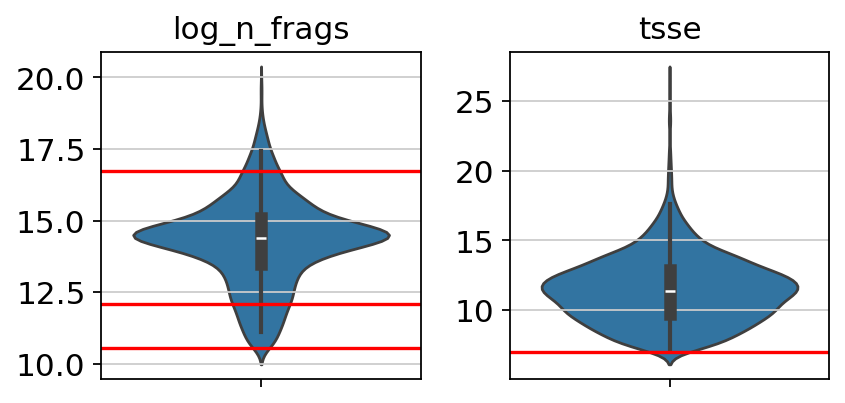

After fragment QC:    3,218 cells × 526,765 features
After feature select: 3,218 cells × 526,765 features
After Scrublet:       3,218 cells × 526,765 features


NameError: name 'adata' is not defined

In [41]:
genome = snap.genome.mm10
snap.metrics.tsse(adata_atac_mm, genome)

print(f"Initial dataset:      "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

snap.pp.filter_cells(adata_atac_mm, min_tsse=7, min_counts=1500,)

print(f"After TSSE/count QC:  "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

snap.pp.add_tile_matrix(adata_atac_mm, bin_size=5000,)
print(f"After tile matrix:    "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

vln_plots, keep = qc(adata_atac_mm)
#SnapATAC2 specific filtering function
adata_atac_mm.subset(keep)

print(f"After fragment QC:    "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

snap.pp.select_features(
    adata_atac_mm,
    n_features=30000,
)
print(f"After feature select: "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

snap.pp.scrublet(adata_atac_mm)
print(f"After Scrublet:       "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

snap.tl.spectral(adata_atac_mm)
snap.tl.umap(adata_atac_mm)
snap.pl.umap(adata_atac_mm, color="tsse")
snap.pl.umap(adata_atac_mm, color="doublet_probability")
snap.pl.umap(adata_atac_mm, color="log_n_frags")
snap.pl.umap(adata_atac_mm)

snap.pp.filter_doublets(adata_atac_mm)
print(f"After doublet filter: "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

adata_atac_mm.write(f"/content/drive/MyDrive/star_protocols_paper/filtered_adata.h5ad")
adata_atac_mm.close()

In [42]:
snap.tl.spectral(adata_atac_mm)
snap.tl.umap(adata_atac_mm)
snap.pl.umap(adata_atac_mm, color="tsse")
snap.pl.umap(adata_atac_mm, color="doublet_probability")
snap.pl.umap(adata_atac_mm, color="log_n_frags")
snap.pl.umap(adata_atac_mm)

snap.pp.filter_doublets(adata_atac_mm)
print(f"After doublet filter: "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

adata_atac_mm.write(f"/content/drive/MyDrive/star_protocols_paper/filtered_adata.h5ad")
adata_atac_mm.close()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


After doublet filter: 2,885 cells × 526,765 features


# Download Consensus Chromatin Landscape peaks - Approx. 1 min

The Consensus Chromatin Landscape includes a reproducible set of accessible genomic regions. For a better understanding, please consult Kövér et al. (2026) in Cell Reports

In [43]:
!wget https://raw.githubusercontent.com/Andoniadou-Lab/consensus_pituitary_atlas/main/Consensus_Chromatin_Landscape/consensus_chromatin_landscape.bed

--2026-07-11 15:16:15--  https://raw.githubusercontent.com/Andoniadou-Lab/consensus_pituitary_atlas/main/Consensus_Chromatin_Landscape/consensus_chromatin_landscape.bed
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5886467 (5.6M) [text/plain]
Saving to: ‘consensus_chromatin_landscape.bed’

consensus_chromatin 100%[===================>]   5.61M  --.-KB/s    in 0.01s   

2026-07-11 15:16:16 (514 MB/s) - ‘consensus_chromatin_landscape.bed’ saved [5886467/5886467]



# Fragment counting in CCL peaks - Approx. 1 min

Fragment counting is performed as opposed to read counting, to remain consistent with the Consensus Pituitary Atlas, and also for reasons discussed in: https://doi.org/10.1038/s41592-023-02112-6

In [44]:
#load back object
import snapatac2 as snap
adata_atac_mm = snap.read("/content/drive/MyDrive/star_protocols_paper/filtered_adata.h5ad")
peak_mat = snap.pp.make_peak_matrix(adata_atac_mm, peak_file= "/content/consensus_chromatin_landscape.bed", counting_strategy = "fragment")
peak_mat.write(f"/content/drive/MyDrive/star_protocols_paper/quantified_adata.h5ad")
adata_atac_mm.close()

/usr/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Now lognormalising the fragment matrix. Also saving over the UMAP from the initial object

In [45]:
adata_atac_mm = snap.read("/content/drive/MyDrive/star_protocols_paper/filtered_adata.h5ad")
peak_mat = snap.read("/content/drive/MyDrive/star_protocols_paper/quantified_adata.h5ad").to_memory()
sc.pp.normalize_total(peak_mat, target_sum=1e4)
sc.pp.log1p(peak_mat)
peak_mat.obsm["X_umap"] = adata_atac_mm.obsm["X_umap"]
adata_atac_mm.close()

 Running epitome_tools - Approx. 1-2 mins

In [46]:
from epitome_tools.workflow import cell_type_workflow
import time

start_mm = time.time()

cell_type_workflow(
  peak_mat,
  modality="atac",
  in_place=True,
  species="mouse",
  smoothing = False )

end_mm = time.time()
print(f"Time taken for dataset: {end_mm - start_mm} seconds")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Percentage of features present in adata: 100.00%
At least 70% of the features are present in the adata object.
The dataset has passed the compatibility check.
Time taken for dataset: 88.63241291046143 seconds


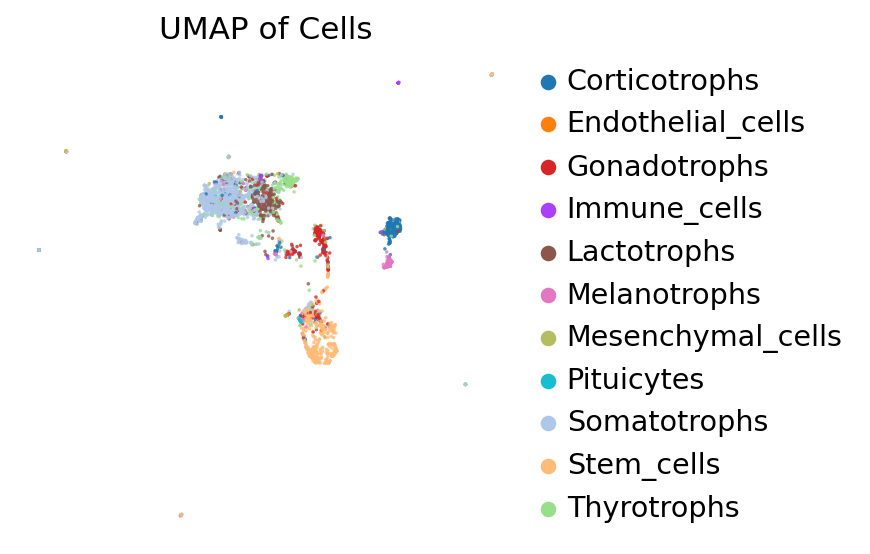

In [57]:
palette = list(sc.pl.palettes.default_20)
palette.pop(2)

def plot_cells(adata,column):
  sc.pl.umap(
      adata,
      color=column,
      size=10,
      alpha=0.8,
      frameon=False,
      title="UMAP of Cells",
      save=f"_{column}_atac.png",
      show=True,
      palette=palette
      )

# Set high-resolution saving
sc.settings.figdir = "./figures"
sc.set_figure_params(dpi_save=800)
plot_cells(peak_mat,'predicted_cell_type')

# Visualising in RNA-space

In [58]:
#download multiome onlist
!wget -P 10xMultiome/ https://teichlab.github.io/scg_lib_structs/data/10X-Genomics/gex_737K-arc-v1.txt.gz
!gunzip 10xMultiome/gex_737K-arc-v1.txt.gz
!wget -P 10xMultiome/ https://teichlab.github.io/scg_lib_structs/data/10X-Genomics/atac_737K-arc-v1.txt.gz
!gunzip 10xMultiome/atac_737K-arc-v1.txt.gz

--2026-07-11 15:26:07--  https://teichlab.github.io/scg_lib_structs/data/10X-Genomics/gex_737K-arc-v1.txt.gz
Resolving teichlab.github.io (teichlab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to teichlab.github.io (teichlab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2142553 (2.0M) [application/gzip]
Saving to: ‘10xMultiome/gex_737K-arc-v1.txt.gz’

gex_737K-arc-v1.txt 100%[===================>]   2.04M  --.-KB/s    in 0.01s   

2026-07-11 15:26:07 (207 MB/s) - ‘10xMultiome/gex_737K-arc-v1.txt.gz’ saved [2142553/2142553]

--2026-07-11 15:26:07--  https://teichlab.github.io/scg_lib_structs/data/10X-Genomics/atac_737K-arc-v1.txt.gz
Resolving teichlab.github.io (teichlab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to teichlab.github.io (teichlab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2465078 (2.4M) [ap

In [59]:
#create mapping from rna to atac barcodes
gex = pd.read_csv("/content/10xMultiome/gex_737K-arc-v1.txt",header=None)
atac = pd.read_csv('/content/10xMultiome/atac_737K-arc-v1.txt',header=None)

#mapping atac to gex
mapping = pd.DataFrame({'gex': gex[0], 'atac': atac[0]})
mapping_atac_to_gex= mapping.set_index('atac')['gex'].to_dict()

#mapping gex to cell type
mapping_gex_ct = adata_mm.obs['predicted_cell_type'].to_dict()

#extracting barcode sequence
peak_mat.obs["barcode"] = (peak_mat.obs_names.astype(str).str.split("-").str[0]
)

#mapping to atac barcode to RNA counterpart, and adding -1 to it
peak_mat.obs["barcode"] = peak_mat.obs["barcode"].map(mapping_atac_to_gex)
peak_mat.obs["barcode"] = peak_mat.obs["barcode"] + "-1"

#add cell type
peak_mat.obs["predicted_cell_type_rna"] = peak_mat.obs["barcode"].map(mapping_gex_ct)

KeyError: 'predicted_cell_type'

In [ ]:
#keep where cell type is not na
peak_mat = peak_mat[peak_mat.obs["predicted_cell_type_rna"].notna()]

shared_barcodes = pd.Index(peak_mat.obs["barcode"]).intersection(adata_mm.obs_names)
peak_mat.obsm["X_umap"] = adata_mm[shared_barcodes].obsm["X_umap"]

In [ ]:
def plot_cells(adata,column):
  sc.pl.umap(
      adata,
      color=column,
      size=10,
      alpha=0.8,
      frameon=False,
      title="UMAP of Cells",
      save=f"_{column}_atac.png",
      show=True,
      palette=palette
      )

# Set high-resolution saving
sc.settings.figdir = "./figures"
sc.set_figure_params(dpi_save=800)
plot_cells(peak_mat,"predicted_cell_type_rna")
plot_cells(peak_mat,"predicted_cell_type")

Quantifying overlap in labels

In [60]:
df = peak_mat.obs[["predicted_cell_type","predicted_cell_type_rna"]]
pct_equal = (df["predicted_cell_type"] == df["predicted_cell_type_rna"]).mean() * 100

print(f"{pct_equal:.2f}%")

KeyError: "['predicted_cell_type_rna'] not in index"

#Saving ATAC data

In [62]:
peak_mat.write("/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac_final.h5ad")

# Visualising known marker peaks

In [ ]:
!wget https://raw.githubusercontent.com/BKover99/epitome_tools_star_protocols/main/cell_typing_markers_atac.csv

In [68]:
# Load the data
ct_markers = pd.read_csv("/content/cell_typing_markers_atac.csv")
ct_markers = ct_markers[ct_markers["avg_expr"] > 1]
# Sort by p-value
ct_markers = ct_markers.sort_values(by="pval")

# Keep the top 5 genes for each cell type
ct_markers = ct_markers.groupby("celltype").head(5)

# Aggregate the genes into a list for each cell type and convert to a dictionary
ct_markers_dict = ct_markers.groupby("celltype")["peak"].apply(list).to_dict()

# View the result
ct_markers_dict

{'Corticotrophs': ['chr18:39255339-39255840',
  'chr11:104132560-104133061',
  'chr1:36794017-36794518',
  'chr1:131569578-131570079',
  'chr18:44498456-44498957'],
 'Endothelial_cells': ['chr11:120142522-120143023',
  'chr16:87661124-87661625',
  'chr1:36571586-36572087',
  'chr16:38713053-38713554',
  'chr6:128102481-128102982'],
 'Gonadotrophs': ['chr5:36936488-36936989',
  'chr3:144438544-144439045',
  'chr6:134975807-134976308',
  'chr4:134805922-134806423',
  'chr9:97013059-97013560'],
 'Immune_cells': ['chr10:80695136-80695637',
  'chr16:11456244-11456745',
  'chr9:47733788-47734289',
  'chr5:149245954-149246455',
  'chr13:81136532-81137033'],
 'Lactotrophs': ['chr13:73117339-73117840',
  'chr13:89881267-89881768',
  'chr11:45274716-45275217',
  'chr6:6173736-6174237',
  'chr7:69126755-69127256'],
 'Melanotrophs': ['chr12:112250800-112251301',
  'chr19:42405835-42406336',
  'chr7:75360925-75361426',
  'chr18:65697730-65698231',
  'chr10:41715622-41716123'],
 'Mesenchymal_cells':

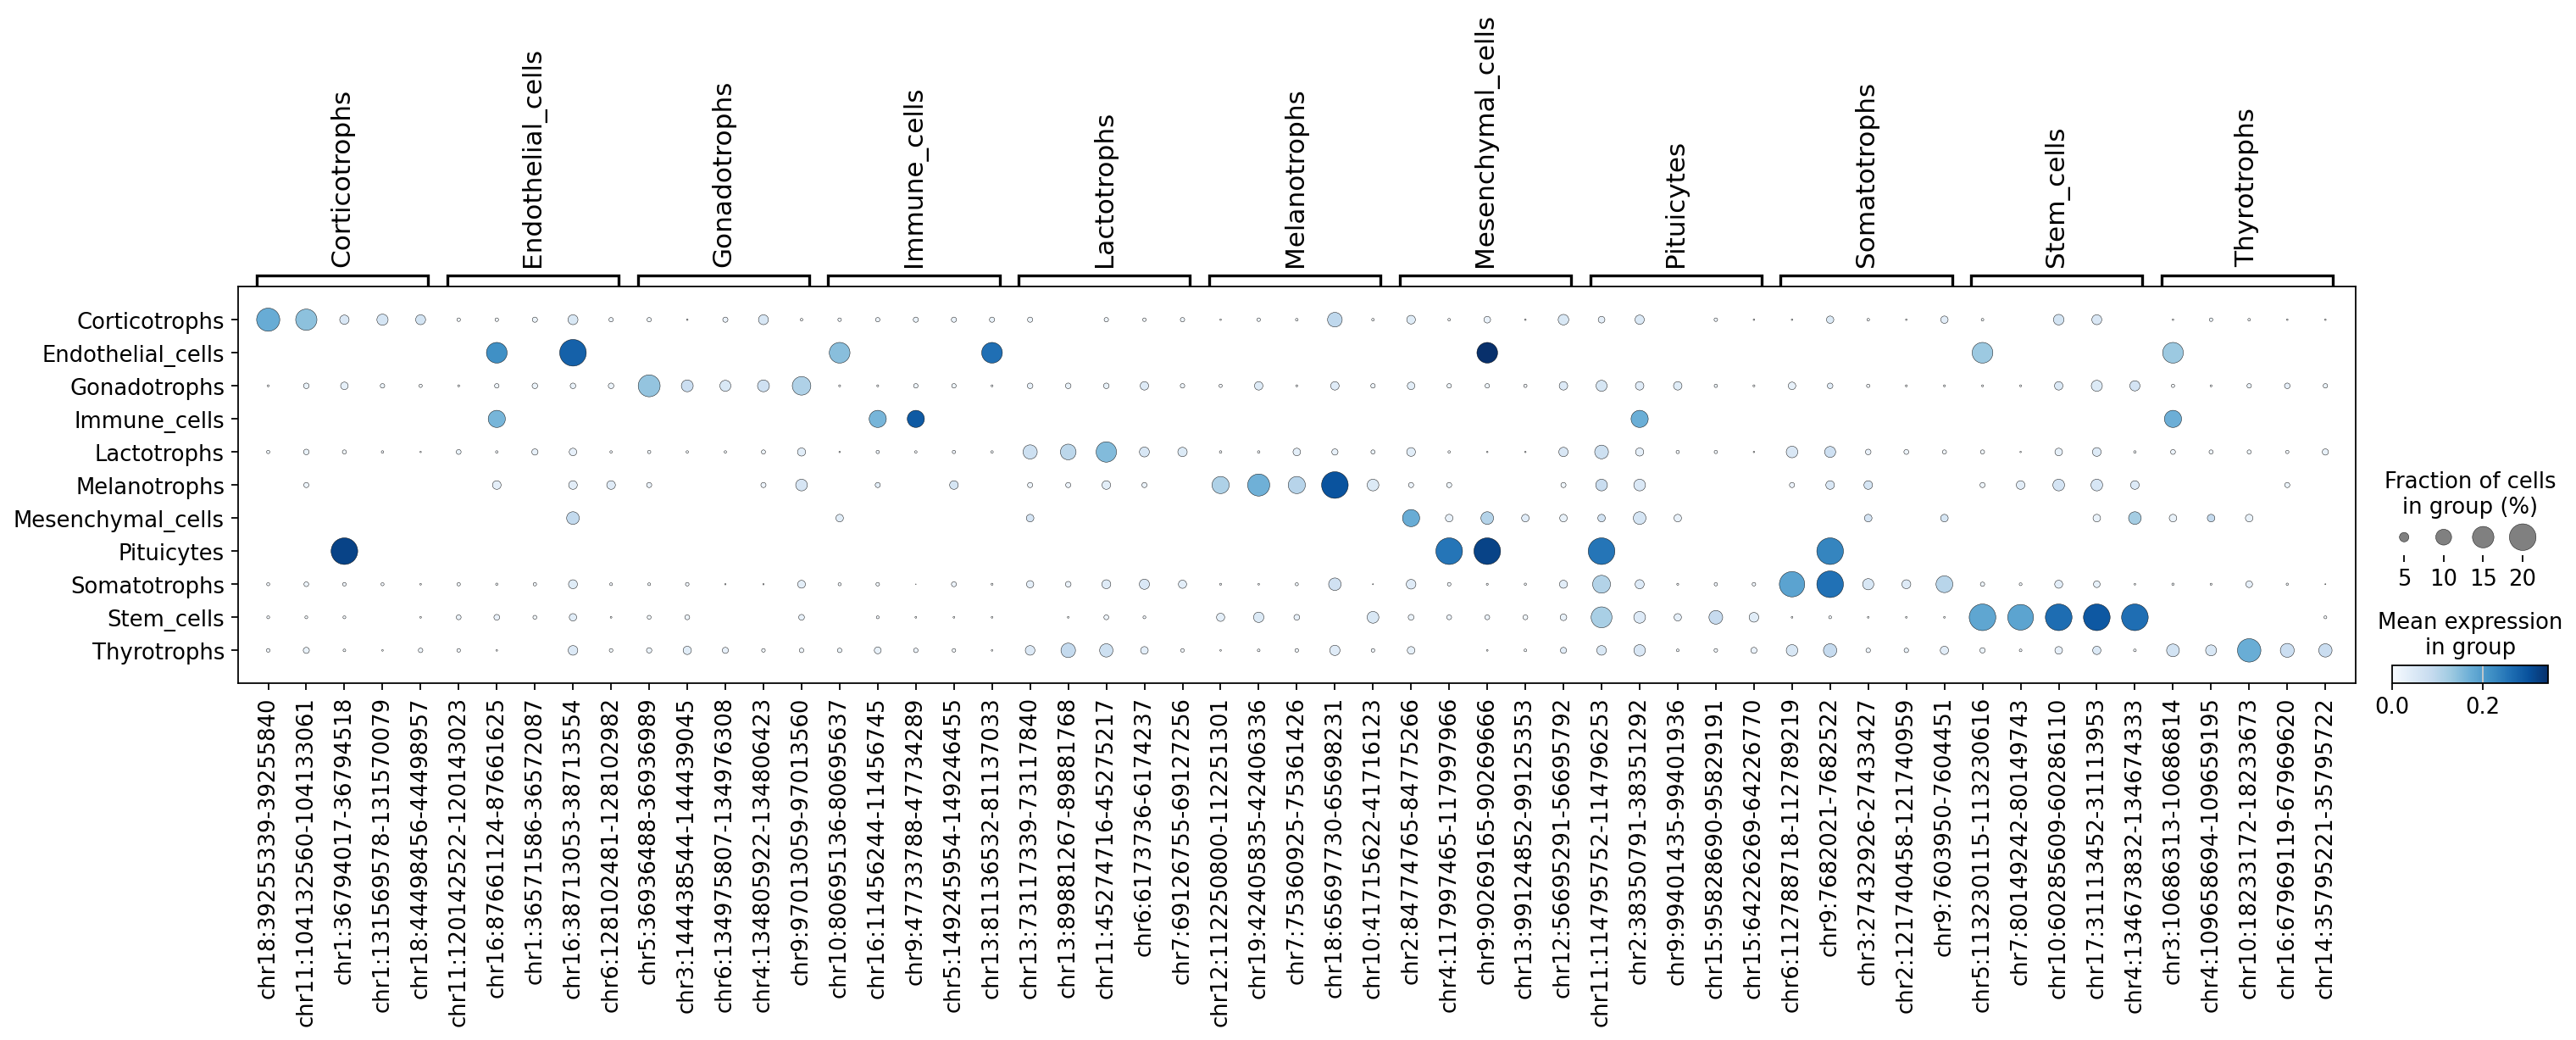

In [69]:
# Filter the marker peaks to those included in the object
ct_markers_dict = {k: [x for x in v if x in peak_mat.var_names] for k, v in ct_markers_dict.items()}

# Extract the intended order from your dictionary keys
cell_type_order = list(ct_markers_dict.keys())

# Cast the observation column to a Categorical type with the strict order
peak_mat.obs["predicted_cell_type"] = pd.Categorical(
    peak_mat.obs["predicted_cell_type"],
    categories=cell_type_order,
    ordered=True
)

sc.pl.dotplot(peak_mat, ct_markers_dict, groupby="predicted_cell_type",save="_dotplot_markers.png",cmap="Blues", dot_max=0.2,use_raw=False)

Print versions for reproducibility

In [ ]:
pip freeze

absl-py==1.4.0
accelerate==1.8.1
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.15
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
altair==5.5.0
anndata==0.12.19
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.9.0
argon2-cffi==25.1.0
argon2-cffi-bindings==21.2.0
array-api-compat==1.15.0
array_record==0.7.2
arviz==0.21.0
astropy==7.1.0
astropy-iers-data==0.2025.7.14.0.40.29
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.10.0
bigquery-magics==0.10.1
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.0.0
blosc2==3.5.1
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.1
build==1.2.2.post1
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2026.6.17
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.9
chex==0.1.89
choreographer==1.3.0
clarabel==0.11.1
click==8.2

In [ ]:
pip freeze

absl-py==1.4.0
accelerate==1.8.1
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.15
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
altair==5.5.0
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.9.0
argon2-cffi==25.1.0
argon2-cffi-bindings==21.2.0
array_record==0.7.2
arviz==0.21.0
astropy==7.1.0
astropy-iers-data==0.2025.7.14.0.40.29
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.10.0
bigquery-magics==0.10.1
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.0.0
blosc2==3.5.1
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.1
build==1.2.2.post1
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.7.14
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.2
chex==0.1.89
clarabel==0.11.1
click==8.2.1
cloudpathlib==0.21.1
cloudpickle==3.1.1
cmake==3.31.6
cmdsta